In [1]:
%load_ext autoreload
%autoreload 2

# Enable packages in project notebook (not required for .py scripts)
import sys
import os

# Add the project root or parent folder to sys.path
sys.path.append(os.path.abspath("../../"))  # or "../../" depending on your structure

import yaml
import pickle
from tqdm import tqdm

import numpy as np
import pandas as pd

import seaborn as sns
palette = sns.color_palette("Paired", 6)

import jax
import optax
import torch
import torch.utils.data as data

import counterfactual_alignment as cfa
from counterfactual_alignment import custom_datasets, custom_models, loss_functions, knowledge_functions
from counterfactual_alignment import utilities as ut

from counterfactual_alignment.pipeline import pipeline


25-Sep-07 15:53:53 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


ImportError: cannot import name 'pipeline' from 'counterfactual_alignment.pipeline' (/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment/counterfactual_alignment/pipeline.py)

In [ ]:
"""
Load tunable parameters from config file 
"""
config_file = "config.yaml" #assuming local yaml file
with open(config_file,'r') as file:
    config = yaml.unsafe_load(file)[0]

overwrite = True

loss_name = config['hyperparams']['loss_function']
learning_rate = config['hyperparams']['learning_rate']
batch_size = config['hyperparams']['batch_size']


In [ ]:
"""
Define learning rate schedule
"""

#simple optimiser
adam = optax.adam(learning_rate=learning_rate)

#complex optimiser
warmup_steps = 3

final_lr = 1e-3

schedule = optax.join_schedules(
    schedules=[
        optax.linear_schedule(init_value=0.0, end_value=learning_rate, transition_steps=warmup_steps),
        optax.exponential_decay(init_value=learning_rate, transition_steps=100, decay_rate=0.9)
    ],
    boundaries=[warmup_steps]
)

chained_optax = optax.chain(
    optax.clip_by_global_norm(1.0),  # Clip gradients
    optax.adam(schedule)
)
optimiser = adam

optim_name = [oname for oname in [name for name, value in locals().items() if value is optimiser] if oname != 'optimiser'][0] #reads optimiser name from local variables (for file name)

In [ ]:
"""
Initialise Parameters
"""

seed = seed=config['hyperparams']['seed']
key = jax.random.PRNGKey(seed)
noise_key,sample_key,model_key = jax.random.split(key,3)

In [ ]:
"""
Gen Datasets
"""

def optimum_classifier(Z):
        """
        Inputs  | z:      x,y coordinates of data to be classified.
        Outputs | probs:  array of probabilities for each class for input data.
        """
        return np.array([int(z[0]>=0) for z in Z])


size = config['data_params']['train_size'] + config['data_params']['validation_size']

X_dims = 2
X = np.array([(x,x**2) for x in np.linspace(-5,5,size)]) + jax.random.normal(noise_key,(size,X_dims))*0.5 # multiply by scaling factor

Y = np.zeros_like(X[:,0])
Y[int(size/2 + size%2):] = 1

y_preds = optimum_classifier(X)

# sample training set
sample_indices = jax.random.randint(sample_key,config['data_params']['train_size'],0,size,)
sample_indices = jax.random.permutation(sample_key,size)[:config['data_params']['train_size']] 

X_train = np.array([X[i] for i in sample_indices])
Y_train = np.array([Y[i] for i in sample_indices])


X_test = np.array([X[i] for i in range(size) if i not in sample_indices])
Y_test = np.array([Y[i] for i in range(size) if i not in sample_indices])

full_df = pd.DataFrame({'x_0':X[:,0],
                         'x_1':X[:,1],
                         'Class':Y})

train_df = pd.DataFrame({'x_0':X_train[:,0],
                         'x_1':X_train[:,1],
                         'Class':Y_train})

test_df = pd.DataFrame({'x_0':X_test[:,0],
                         'x_1':X_test[:,1],
                         'Class':Y_test})



### Add path of points between observation and counterfactual

In [ ]:
n_samples = 3

knowledge = knowledge_functions.counterfactual_vector_paths(X_train,Y_train,classifier=optimum_classifier,n_samples=n_samples)

K_X = knowledge['origin'].reshape(int(n_samples*config['data_params']['train_size']),X_dims)
K_Y = np.array([[y]*n_samples for y in Y_train]).reshape(int(n_samples*config['data_params']['train_size']))

K_df = pd.DataFrame({'x_0':K_X[:,0],
                      'x_1':K_X[:,1],
                      'Class':K_Y})

Generating 3 counterfactual samples per observation ...


2it [00:00, 334.62it/s]


### Visualise

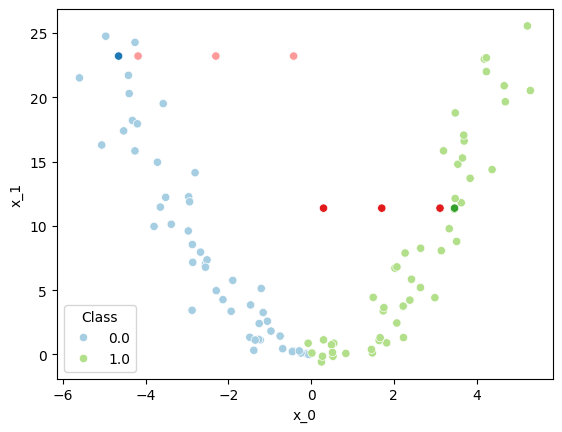

In [ ]:

if config['visualisation']['visualise']:
#     fulldata_scatter = sns.scatterplot(data=full_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]],alpha=0.5,s=5,legend=False)
    test_scatter = sns.scatterplot(data=test_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]])
    K_scatter = sns.scatterplot(data=K_df,x='x_0',y='x_1',hue='Class',palette=[palette[4],palette[5]],legend=False)
    train_scatter = sns.scatterplot(data=train_df,x='x_0',y='x_1',hue='Class',palette=[palette[1],palette[3]],legend=False)
    

### Method 0
#### Baseline

In [ ]:
datasets = {'train' :data.TensorDataset(torch.tensor(X_train),torch.tensor(Y_train)),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test))}

In [ ]:
datasets = {'train' :data.TensorDataset(torch.tensor(X_train),torch.tensor(Y_train)),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test))}
pipeline(datasets,data_description="",method_description="baseline",overwrite=True)

Loading and saving to :  MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_2__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline


  0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.6094784140586853, Train Accuracy: 50.0


100%|██████████| 10/10 [00:02<00:00,  3.55it/s]

Validation Loss: 0.6365329027175903, Validation Accuracy: 58.999996185302734
Train Loss: 0.6230854988098145, Train Accuracy: 50.0
Validation Loss: 0.6372090578079224, Validation Accuracy: 58.0
Train Loss: 0.6359261274337769, Train Accuracy: 50.0
Validation Loss: 0.6381192803382874, Validation Accuracy: 55.0
Train Loss: 0.6467640399932861, Train Accuracy: 50.0
Validation Loss: 0.6390211582183838, Validation Accuracy: 53.999996185302734
Train Loss: 0.6549473404884338, Train Accuracy: 50.0
Validation Loss: 0.639721691608429, Validation Accuracy: 56.0
Train Loss: 0.6603474617004395, Train Accuracy: 50.0
Validation Loss: 0.6400806307792664, Validation Accuracy: 58.999996185302734
Train Loss: 0.6631712913513184, Train Accuracy: 50.0
Validation Loss: 0.6399993896484375, Validation Accuracy: 59.999996185302734
Train Loss: 0.6637964248657227, Train Accuracy: 50.0
Validation Loss: 0.6394054293632507, Validation Accuracy: 59.999996185302734
Train Loss: 0.6626845002174377, Train Accuracy: 50.0
Val

### Method 1
#### Add paths as observations with labels

In [ ]:
#Adding K to X

X_train = np.concatenate((X_train,K_X))
Y_train = np.concatenate((Y_train,K_Y))

method_description = "add_K_to_X"

In [ ]:
datasets = {'train' :data.TensorDataset(torch.tensor(X_train),torch.tensor(Y_train)),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test))}
pipeline(datasets,data_description="",method_description="baseline_with_K",overwrite=True)


Loading and saving to :  MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline_with_K


100%|██████████| 10/10 [00:01<00:00,  6.32it/s]

Train Loss: 0.632911741733551, Train Accuracy: 75.0
Validation Loss: 0.6297820210456848, Validation Accuracy: 66.0
Train Loss: 0.6178983449935913, Train Accuracy: 75.0
Validation Loss: 0.6244735717773438, Validation Accuracy: 70.0
Train Loss: 0.6041756868362427, Train Accuracy: 87.5
Validation Loss: 0.6190206408500671, Validation Accuracy: 74.0
Train Loss: 0.5916721820831299, Train Accuracy: 87.5
Validation Loss: 0.6134960651397705, Validation Accuracy: 78.0
Train Loss: 0.5807899832725525, Train Accuracy: 100.0
Validation Loss: 0.6083130240440369, Validation Accuracy: 79.0
Train Loss: 0.5717664957046509, Train Accuracy: 87.5
Validation Loss: 0.6035369634628296, Validation Accuracy: 79.99999237060547
Train Loss: 0.5646280646324158, Train Accuracy: 87.5
Validation Loss: 0.5990955829620361, Validation Accuracy: 83.0
Train Loss: 0.5590939521789551, Train Accuracy: 87.5
Validation Loss: 0.5948541760444641, Validation Accuracy: 87.0
Train Loss: 0.5546208024024963, Train Accuracy: 87.5
Valida

outputs/MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_2__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline.pkl
FILE:  outputs/MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_2__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline.pkl
outputs/MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline_with_K.pkl
FILE:  outputs/MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline_with_K.pkl


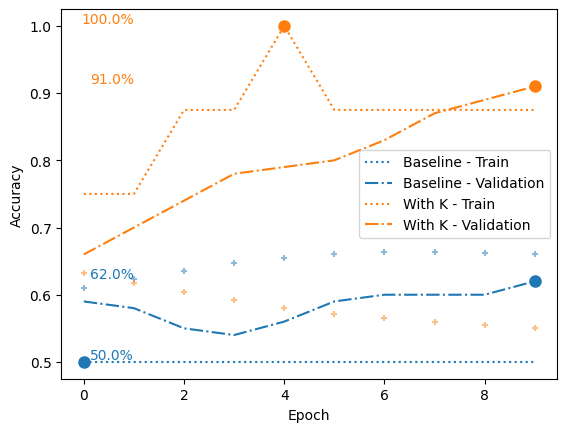

In [ ]:
names= ["MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_2__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline",
        "MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline_with_K"]

res = []


for output_name in names:
        print(os.path.join('outputs',output_name+'.pkl'))
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                print("FILE: ",file.name)
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])
